# ANA500 Micro-Project 2 - Adult Income Dataset

Jesus Adrian Alvarado Gadea
ANA500, National University

Micro-Project 2 uses visualization libraries (Matplotlib and Seaborn) to analyze the Adult
Income dataset prepared in Micro-Project 1. Per the assignment, it runs through Step 4
(Report). No models are built, that starts in Micro-Project 3.

**Problem statement:** Earnings in the 1994 US workforce were spread unevenly across
demographic and employment characteristics. People working similar hours ended up at very
different income levels. I want to describe which recorded attributes are associated with
earning more than $50,000 a year.

**Hypothesis:** Education and hours worked per week are the strongest correlates of earning
above $50,000, with occupation and marital status adding some additional signal. In this
micro-project the hypothesis gets examined visually. The formal test with models comes in
Micro-Project 3.

In [1]:
# visualization libraries are the focus of this micro-project
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

# one consistent color per income class across every figure
COLORS = {"<=50K": "#4C72B0", ">50K": "#DD8452"}

# figures get saved here for the slide deck
Path("fig").mkdir(exist_ok=True)

print("matplotlib", plt.matplotlib.__version__, "| seaborn", sns.__version__)

matplotlib 3.10.8 | seaborn 0.13.2


## Step 1 - Acquire

The dataset is the Adult (Census Income) extract from the UCI Machine Learning Repository,
dataset ID 2. Citation: Becker, B. and Kohavi, R. (1996). Adult [Dataset]. UCI Machine
Learning Repository. https://doi.org/10.24432/C5XW20. Licensed CC BY 4.0.

Micro-Project 1 already retrieved the raw files, cleaned them, and saved the result as
adult_income_prepared.csv. This project loads that prepared file directly, so the acquire
step here is short. The file has 48,790 rows and 22 columns, including the derived columns
built in Micro-Project 1 (education_tier, hours_band, age_band, capital indicators, and the
binary target income_gt_50k).

In [2]:
# prepared output of Micro-Project 1
df = pd.read_csv("data/adult_income_prepared.csv")

print(df.shape)
print(df.columns.tolist())

(48790, 22)
['age', 'workclass', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income', 'income_gt_50k', 'capital_gain_topcoded', 'has_capital_gain', 'has_capital_loss', 'net_capital', 'capital_gain_log', 'education_tier', 'hours_band', 'age_band']


## Step 2 - Prepare

The heavy preparation happened in Micro-Project 1: missing values became an explicit
Unknown category, fnlwgt and the redundant education text column were dropped, 52 exact
duplicates were removed, and the capital top-code at 99999 was flagged. The main decisions
that matter for reading the charts below:

- Rows with Unknown workclass/occupation were kept because they earn well below average.
- Nothing was deleted as an outlier, every observed value is plausible.
- The target is imbalanced at about 76/24 and was left that way on purpose.

The only preparation needed here is restoring category order. CSV files do not remember
that the banded columns have a natural order, and without it the charts would sort
alphabetically.

In [3]:
# the CSV round trip loses category ordering, so it gets set back here
# each banded column gets its natural order back
orders = {
    "education_tier": ["No-HS-diploma", "HS-graduate", "Some-college", "Bachelors-plus"],
    "hours_band": ["Part-time", "Full-time", "Overtime", "Long-hours"],
    "age_band": ["17-24", "25-34", "35-44", "45-54", "55-64", "65-plus"],
    "income": ["<=50K", ">50K"],
}
for col, order in orders.items():
    df[col] = pd.Categorical(df[col], categories=order, ordered=True)

# quick sanity checks before plotting anything
print("rows:", len(df))
print("missing cells:", int(df.isna().sum().sum()))
print("share above 50K:", round(df["income_gt_50k"].mean() * 100, 2), "%")

rows: 48790
missing cells: 0
share above 50K: 23.94 %


In [4]:
# overall rate, drawn on several charts as a reference line
BASE_RATE = df["income_gt_50k"].mean() * 100

# helper used throughout: share above 50K for each level of a column
def rate_by(col):
    # mean of a 0/1 column is the share of ones
    return (df.groupby(col, observed=True)["income_gt_50k"].mean() * 100)

print("baseline:", round(BASE_RATE, 2), "%")

baseline: 23.94 %


## Step 3 - Analyze

The analytical technique for this micro-project is visual exploratory analysis. The chart
type follows from the data types involved:

- One numeric column by income class: overlaid histograms or density curves.
- One categorical column against the binary target: the share above 50K per level, drawn as
  a bar chart with the 23.9% overall rate as a reference line.
- Two categorical columns against the target: a heatmap of the rate in each cell.

The figures are ordered by the hypothesis. Education and hours come first since the
hypothesis names them as the dominant pair, then their joint effect, then the secondary
variables (occupation, marital status), then age and capital, and finally the demographic
columns that were kept for fairness reasons.

## Step 4 - Report

### Figure 1: the target itself

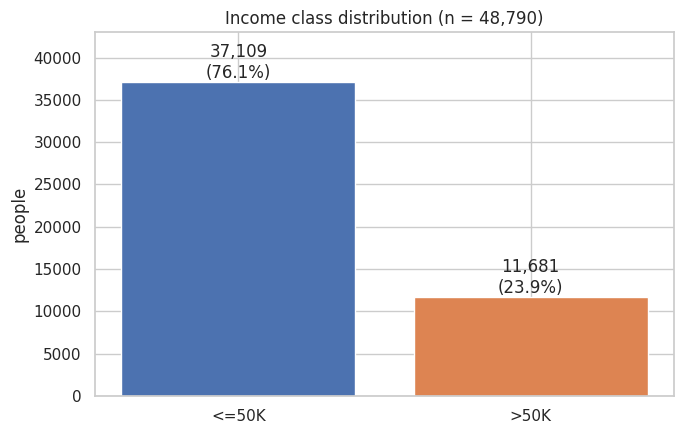

In [5]:
# how imbalanced is the outcome
fig, ax = plt.subplots(figsize=(7, 4.5))
counts = df["income"].value_counts().sort_index()  # keep <=50K first
bars = ax.bar(counts.index.astype(str), counts.values,
              color=[COLORS[c] for c in counts.index.astype(str)])

# label each bar with count and share so the imbalance is readable at a glance
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 500,
            f"{v:,}\n({v / len(df) * 100:.1f}%)", ha="center")

ax.set_ylim(0, 43000)
ax.set_ylabel("people")
ax.set_title("Income class distribution (n = 48,790)")
fig.tight_layout()
fig.savefig("fig/fig01_target.png", dpi=150, bbox_inches="tight")
plt.show()

About one person in four is above the threshold. Every rate chart below should be read
against that 23.9% baseline.

### Figure 2: education

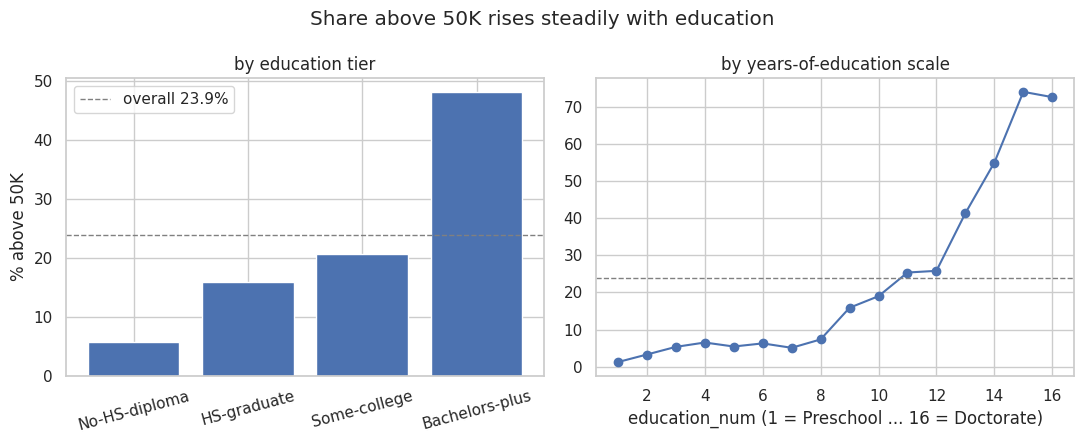

education_tier
No-HS-diploma      5.7
HS-graduate       15.9
Some-college      20.6
Bachelors-plus    48.1
Name: income_gt_50k, dtype: float64


In [6]:
# two views of the same variable: coarse tiers and the full ordinal scale
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# left panel: the four education tiers
r = rate_by("education_tier")
axes[0].bar(r.index.astype(str), r.values, color="#4C72B0")
axes[0].axhline(BASE_RATE, color="gray", ls="--", lw=1, label=f"overall {BASE_RATE:.1f}%")
axes[0].set_ylabel("% above 50K")
axes[0].set_title("by education tier")
axes[0].tick_params(axis="x", rotation=15)
axes[0].legend()

# right panel: the full 16-point ordinal scale
r16 = rate_by("education_num")
axes[1].plot(r16.index, r16.values, marker="o", color="#4C72B0")
axes[1].axhline(BASE_RATE, color="gray", ls="--", lw=1)
axes[1].set_xlabel("education_num (1 = Preschool ... 16 = Doctorate)")
axes[1].set_title("by years-of-education scale")

fig.suptitle("Share above 50K rises steadily with education")
fig.tight_layout()
fig.savefig("fig/fig02_education.png", dpi=150, bbox_inches="tight")
plt.show()

print(r.round(1))

The gradient is large and monotonic. Under 6% of people without a high school diploma are
above the threshold against about 48% of those with a bachelor's degree or higher, and
the point-by-point scale shows the rate climbing at nearly every step. This is the pattern
the hypothesis predicted for its primary variable.

### Figure 3: hours worked

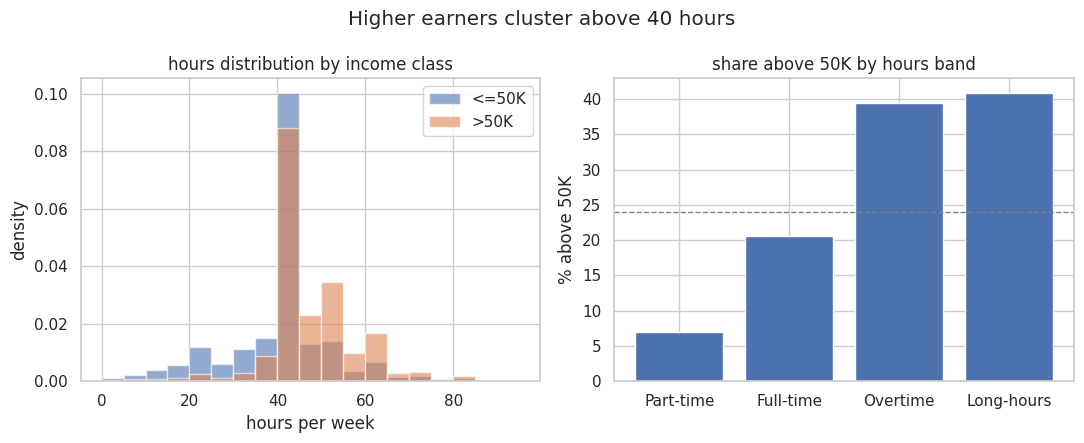

hours_band
Part-time      6.9
Full-time     20.6
Overtime      39.5
Long-hours    40.9
Name: income_gt_50k, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# left panel: where the hours actually fall, by income class
# density=True puts both classes on the same scale despite the 76/24 imbalance
for cls in ["<=50K", ">50K"]:
    axes[0].hist(df.loc[df["income"] == cls, "hours_per_week"],
                 bins=range(0, 100, 5), density=True, alpha=0.6,
                 color=COLORS[cls], label=cls)
axes[0].set_xlabel("hours per week")
axes[0].set_ylabel("density")
axes[0].set_title("hours distribution by income class")
axes[0].legend()

# right panel: rate per hours band
r = rate_by("hours_band")
axes[1].bar(r.index.astype(str), r.values, color="#4C72B0")
axes[1].axhline(BASE_RATE, color="gray", ls="--", lw=1)
axes[1].set_ylabel("% above 50K")
axes[1].set_title("share above 50K by hours band")

fig.suptitle("Higher earners cluster above 40 hours")
fig.tight_layout()
fig.savefig("fig/fig03_hours.png", dpi=150, bbox_inches="tight")
plt.show()

print(r.round(1))

Both classes spike at 40 hours, but the above-50K group carries far more weight in the
41-60 range. The band chart makes the same point as a rate: part-time work almost never
crosses the threshold (about 7%), overtime and long-hours bands sit near 40%. The
second hypothesis variable also behaves as predicted, though the jump from Full-time to
Overtime is larger than the jump from Overtime to Long-hours, so the return on extra hours
flattens.

### Figure 4: education and hours together

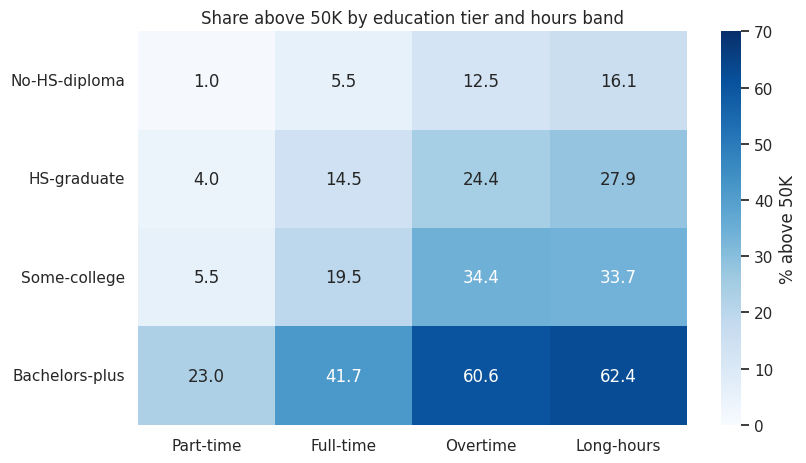

In [8]:
# joint rate across the two hypothesis variables
# pivot_table computes the mean of the 0/1 target, which is the rate per cell
pivot = df.pivot_table(index="education_tier", columns="hours_band",
                       values="income_gt_50k", aggfunc="mean", observed=True) * 100

fig, ax = plt.subplots(figsize=(8.5, 4.8))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Blues", vmin=0, vmax=70,
            cbar_kws={"label": "% above 50K"}, ax=ax)
ax.set_title("Share above 50K by education tier and hours band")
ax.set_xlabel("")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig("fig/fig04_edu_hours.png", dpi=150, bbox_inches="tight")
plt.show()

The two variables stack rather than substitute. Reading any row left to right, more hours
raise the rate at every education level. Reading any column top to bottom, more education
raises the rate at every hours level. The corners are far apart: 1% for
part-time workers without a diploma, over 60% for degree holders working past 50 hours. Education moves the rate more than hours does, which matches the ordering in the
hypothesis.

### Figure 5: occupation

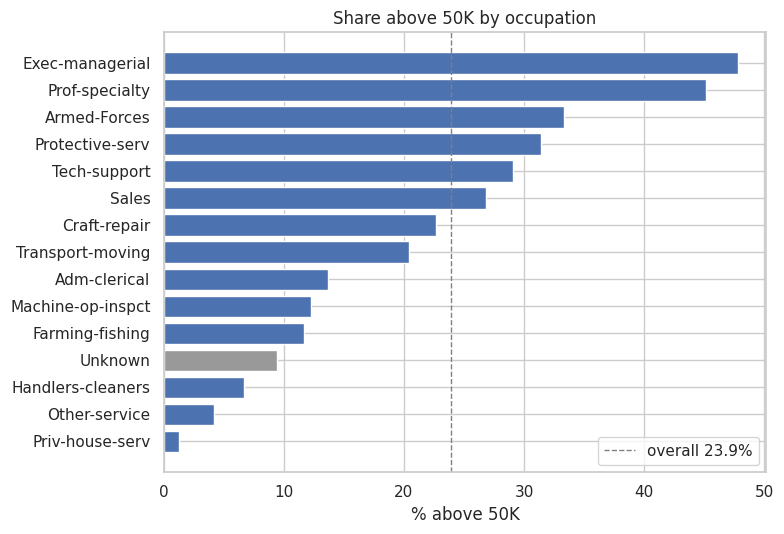

occupation
Armed-Forces       33.3
Prof-specialty     45.1
Exec-managerial    47.8
Name: income_gt_50k, dtype: float64
occupation
Priv-house-serv      1.2
Other-service        4.1
Handlers-cleaners    6.7
Name: income_gt_50k, dtype: float64


In [9]:
# occupations sorted by rate, with the Unknown group included
r = rate_by("occupation").sort_values()

fig, ax = plt.subplots(figsize=(8, 5.5))
# grey out the Unknown level so it reads as a special group, not another occupation
colors = ["#999999" if idx == "Unknown" else "#4C72B0" for idx in r.index]
ax.barh(r.index.astype(str), r.values, color=colors)
ax.axvline(BASE_RATE, color="gray", ls="--", lw=1, label=f"overall {BASE_RATE:.1f}%")
ax.set_xlabel("% above 50K")
ax.set_title("Share above 50K by occupation")
ax.legend()
fig.tight_layout()
fig.savefig("fig/fig05_occupation.png", dpi=150, bbox_inches="tight")
plt.show()

print(r.round(1).tail(3))
print(r.round(1).head(3))

The spread across occupations is nearly as wide as the education gradient: executive and
professional roles sit around 45 to 48%, private household service at about 1%. The Unknown
group (grey bar) lands near 10%, well below the baseline, which is the Micro-Project 1
finding drawn on a chart: the people whose occupation is missing earn less, so deleting
them would have biased the sample upward.

### Figure 6: marital status

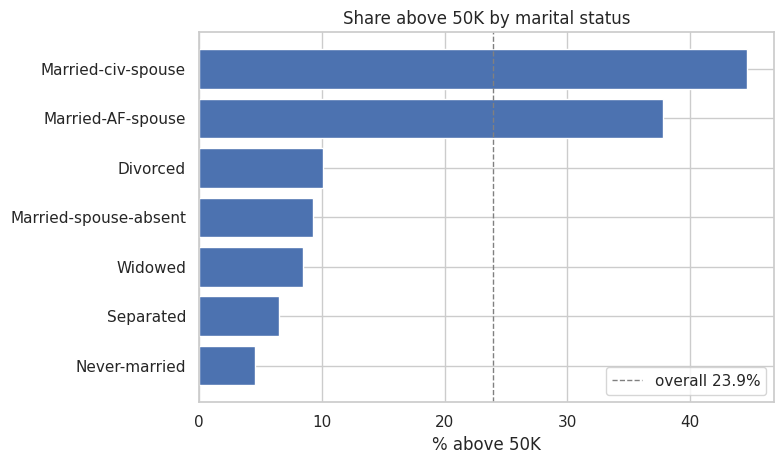

marital_status
Never-married             4.6
Separated                 6.5
Widowed                   8.4
Married-spouse-absent     9.3
Divorced                 10.1
Married-AF-spouse        37.8
Married-civ-spouse       44.6
Name: income_gt_50k, dtype: float64


In [10]:
# horizontal bars because the category names are long
r = rate_by("marital_status").sort_values()

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.barh(r.index.astype(str), r.values, color="#4C72B0")
ax.axvline(BASE_RATE, color="gray", ls="--", lw=1, label=f"overall {BASE_RATE:.1f}%")
ax.set_xlabel("% above 50K")
ax.set_title("Share above 50K by marital status")
ax.legend()
fig.tight_layout()
fig.savefig("fig/fig06_marital.png", dpi=150, bbox_inches="tight")
plt.show()

print(r.round(1))

The two married-with-spouse categories sit far above everything else, about 45% for
civilian spouses and 38% for the small armed-forces group, while every other status lands
around 10% or below. The gap is larger than I expected for a secondary variable, large enough that Micro-Project
3 should check whether it holds once education and hours are controlled, or whether married
respondents simply have more education and hours.

### Figure 7: age

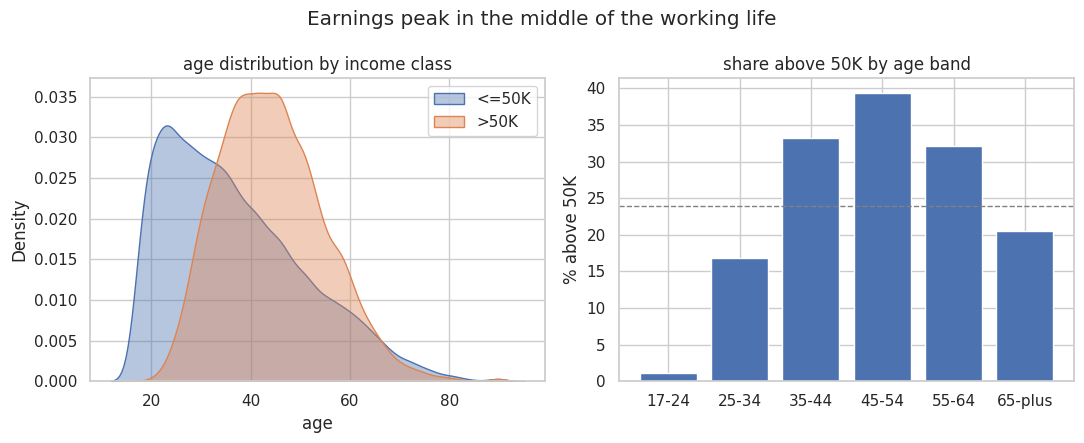

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# left panel: age distribution by class
# KDE instead of histogram since age is smooth and the classes overlap a lot
for cls in ["<=50K", ">50K"]:
    sns.kdeplot(df.loc[df["income"] == cls, "age"], ax=axes[0],
                color=COLORS[cls], label=cls, fill=True, alpha=0.4)
axes[0].set_xlabel("age")
axes[0].set_title("age distribution by income class")
axes[0].legend()

# right panel: rate per decade band
r = rate_by("age_band")
axes[1].bar(r.index.astype(str), r.values, color="#4C72B0")
axes[1].axhline(BASE_RATE, color="gray", ls="--", lw=1)
axes[1].set_ylabel("% above 50K")
axes[1].set_title("share above 50K by age band")

fig.suptitle("Earnings peak in the middle of the working life")
fig.tight_layout()
fig.savefig("fig/fig07_age.png", dpi=150, bbox_inches="tight")
plt.show()

The above-50K density is centered around the mid 40s while the below-50K group skews young.
The band chart shows the rate rising through the 30s and 40s, peaking near 39% in the 45-54
band, then falling after 65. Age was not named in the hypothesis, but it clearly carries
signal and belongs in the Micro-Project 3 models.

### Figure 8: capital gains

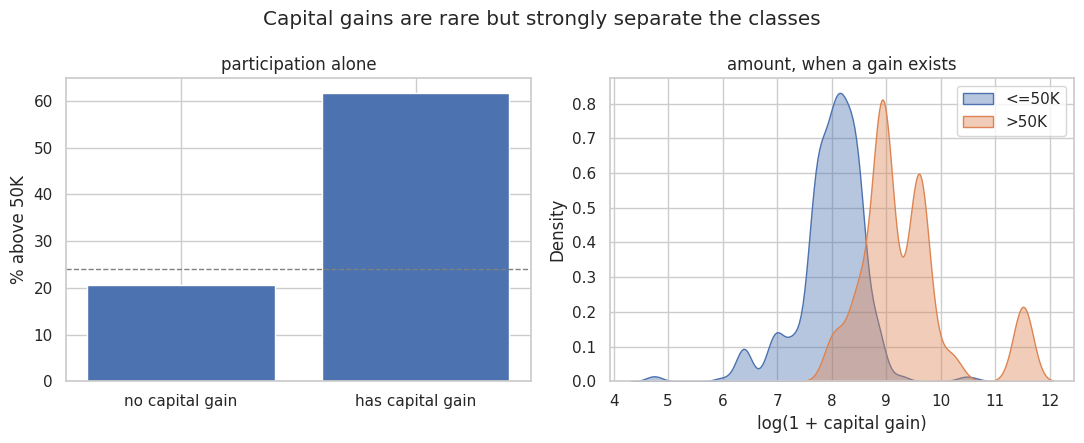

share of sample with any gain: 8.3 %
rate with a gain: 61.7 | rate without: 20.5


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# left panel: having any gain at all
r = df.groupby("has_capital_gain", observed=True)["income_gt_50k"].mean() * 100
axes[0].bar(["no capital gain", "has capital gain"], r.values, color="#4C72B0")
axes[0].axhline(BASE_RATE, color="gray", ls="--", lw=1)
axes[0].set_ylabel("% above 50K")
axes[0].set_title("participation alone")

# right panel: among people with gains, the log amount by class
gains = df[df["capital_gain"] > 0]  # the log-amount panel only makes sense for gains
for cls in ["<=50K", ">50K"]:
    sns.kdeplot(gains.loc[gains["income"] == cls, "capital_gain_log"], ax=axes[1],
                color=COLORS[cls], label=cls, fill=True, alpha=0.4)
axes[1].set_xlabel("log(1 + capital gain)")
axes[1].set_title("amount, when a gain exists")
axes[1].legend()

fig.suptitle("Capital gains are rare but strongly separate the classes")
fig.tight_layout()
fig.savefig("fig/fig08_capital.png", dpi=150, bbox_inches="tight")
plt.show()

print("share of sample with any gain:", round(df["has_capital_gain"].mean() * 100, 1), "%")
print("rate with a gain:", round(r.iloc[1], 1), "| rate without:", round(r.iloc[0], 1))

Only about 8% of the sample reports any capital gain, but among them the above-50K rate
reaches about 62%, more than two and a half times the baseline. The amount separates the classes further: the two densities
barely overlap, with the above-50K group concentrated at the high end of the log scale.
This supports the Micro-Project 1 decision to build the participation flag, since the
yes/no signal does most of the work.

### Figure 9: sex and race

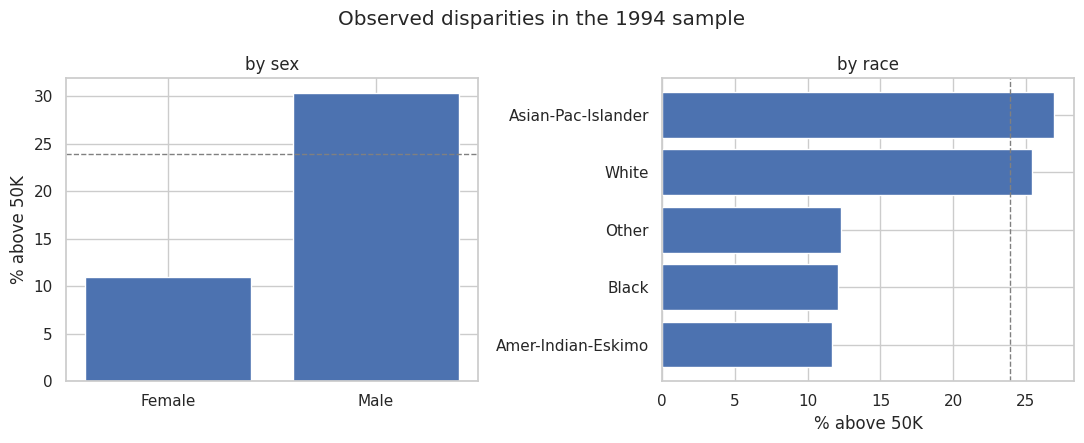

In [13]:
# kept in the data for fairness assessment, documented here as observed gaps
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# same rate-bar treatment as the other categoricals, no special styling
r = rate_by("sex")
axes[0].bar(r.index.astype(str), r.values, color="#4C72B0")
axes[0].axhline(BASE_RATE, color="gray", ls="--", lw=1)
axes[0].set_ylabel("% above 50K")
axes[0].set_title("by sex")

r = rate_by("race").sort_values()
axes[1].barh(r.index.astype(str), r.values, color="#4C72B0")
axes[1].axvline(BASE_RATE, color="gray", ls="--", lw=1)
axes[1].set_xlabel("% above 50K")
axes[1].set_title("by race")

fig.suptitle("Observed disparities in the 1994 sample")
fig.tight_layout()
fig.savefig("fig/fig09_sex_race.png", dpi=150, bbox_inches="tight")
plt.show()

The gaps are large: roughly 30% of men against 11% of women, and a spread of about 15
points across racial groups. These are observed associations in a 1994 sample, not causal
claims, and part of the gap will overlap with occupation, hours, and education. The reason
to chart them is the one stated in Micro-Project 1: any model built on this data should be
checked for how it behaves across these groups, and that check needs the disparity
documented first.

### Findings summary

What the nine figures say about the hypothesis:

- Education behaves as the dominant variable. The rate climbs from under 6% to about 48%
  across the four tiers, monotonically along the full 16-point scale.
- Hours worked also tracks the target as predicted, from about 7% part-time to about 41%
  in the long-hours band, though the effect flattens past 50 hours.
- The heatmap shows the two stack: each raises the rate at every level of the other, and
  education moves it more.
- Occupation spreads nearly as wide as education, and marital status separates more
  sharply than expected for a secondary variable. Both belong in the models.
- Age and capital-gain participation carry clear signal that the hypothesis did not name.
- The sample shows large sex and race gaps, documented here so the Micro-Project 3 models
  can be checked against them.

The visual evidence is consistent with the hypothesis, with one surprise (marital status)
and two additions (age, capital participation). None of this is a test. Association charts
cannot separate the variables from each other, which is exactly what the regression models
in Micro-Project 3 are for.

## Where this stops

The assignment has Micro-Project 2 ending at Step 4 (Report). Step 5 (Act) is out of scope
and comes in Micro-Project 3, where the hypothesis gets its formal test.

Limitations carry over from Micro-Project 1: this is 1994 Census data and describes that
year, not the current labor market, and everything shown is an association drawn from an
observational sample.